# Classificação com MLPs

Naturalmente, as MLPs também podem ser utilizadas para tarefas de classificação. Para um problema de classificação binária, você só precisa de um único neurônio de saída e da função de ativação logística: a saída será um número entre 0 e 1, que você pode interpretar como a probabilidade estimada da classe positiva. A probabilidade estimada da classe negativa é igual a 1 menos esse número.

As MLPs também podem lidar facilmente com tarefas de classificação binária de múltiplos rótulos. Por exemplo, você pode ter um sistema de classificação de e-mail que prediz se cada e-mail recebido é um "não spam" ou um "spam" e, simultaneamente, se é um e-mail "urgente" ou "não urgente". Nesse caso, você só precisaria de dois neurônios de saída, ambos empregando a função de ativação logística: o primeiro geraria a probabilidade de o e-mail ser spam e o segundo geraria a probabilidade de ser urgente. **Em termos gerais, você dedica um neurônio de saída para cada classe positiva.** Nesse caso, as probabilidades de saída não necessariamente somam 1. Isso permite que o modelo gere a saída de qualquer combinação de rótulos: você pode ter um não spam não urgente; um não spam urgente; um spam não urgente e até um spam urgente.

Se cada instância pode pertencer somente a uma única classe, dentre três ou mais classes possíveis (por exemplo, classes de 0 a 9 para a classificação de imagem com algarismos), é necessário ter um neurônio de saída por classe e usar a função de ativação softmax em toda a camada de saída. A função softmax garantirá que todas as probabilidades estimadas fiquem entre 0 e 1 e que somem até 1. É um classificador multiclasse.

Com relação a função de perda, uma vez que estamos predizendo distribuições de probabilidade, a perda de entropia cruzada (log loss) geralmente é uma boa escolha.

A tabela abaixo, resume a típica arquitetura de uma MLP de classificação:

<p align=center>
<img src="https://github.com/vitorbeltrao/Pictures/blob/main/arq_tipica_mlp_classificacao.png?raw=true" width="50%"></p>

Vamos implementar uma MLP em um exemplo prático. Vamos utilizar a biblioteca [TensorFlow](https://www.tensorflow.org/) para isso.

In [22]:
# importar os pacotes necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import string
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vitorabdo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/vitorabdo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/vitorabdo/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# carregar o conjunto de dados: IMDB dataset
splits = {'train': 'plain_text/train-00000-of-00001.parquet', 'test': 'plain_text/test-00000-of-00001.parquet', 'unsupervised': 'plain_text/unsupervised-00000-of-00001.parquet'}
df_train = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["train"], engine="fastparquet")
df_test = pd.read_parquet("hf://datasets/stanfordnlp/imdb/" + splits["test"], engine="fastparquet")

/Users/vitorabdo/Desktop/personal_work/dl_book/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# verificar o tamanho dos dados de treino e teste
print("Tamanho do conjunto de dados de treino:", len(df_train))
print("Tamanho do conjunto de dados de teste:", len(df_test))

Tamanho do conjunto de dados de treino: 25000
Tamanho do conjunto de dados de teste: 25000


Repare que o conjunto de dados já está dividido em um conjunto de treinamento e em um conjunto de testes, no entanto, não existe um conjunto de validação, vamos criar um.

In [4]:
# criando conjunto de validação
df_train, df_val = train_test_split(
    df_train, test_size=0.20, random_state=42)

In [5]:
# verificar o tamanho dos dados de treino e validação
print("Tamanho do conjunto de dados de treino:", len(df_train))
print("Tamanho do conjunto de dados de validação:", len(df_val))

Tamanho do conjunto de dados de treino: 20000
Tamanho do conjunto de dados de validação: 5000


In [6]:
df_train

,text,label
23311,I borrowed this movie despite its extremely lo...,1
23623,After the unexpected accident that killed an i...,1
1020,On the 1998 summer blockbuster hit BASEketball...,0
12645,Can Scarcely Imagine a Better Movie Than This<...,1
1533,A still famous but decadent actor (Morgan Free...,0
...,...,...
21575,My discovery of the cinema of Jan Svankmajer o...,1
5390,The story is similar to ET: an extraterrestria...,0
860,I have read the novel Reaper of Ben Mezrich a ...,0
15795,Went to see this finnish film and I've got to ...,1


Antes de começarmos a construir a rede neural para treinar nossos dados, vamos fazer uma etapa de pré-processamento necessária!

## Pré-processamento dos dados

In [7]:
class CleanText(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned = []

        for text in X:
            text = str(text).lower()
            text = re.sub(r'\[.*?\]', '', text)
            text = re.sub(r'https?://\S+|www\.\S+', '', text)
            text = re.sub(r'<.*?>+', '', text)
            text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
            text = re.sub(r'\n', '', text)
            text = re.sub(r'\w*\d\w*', '', text)
            text = re.sub(r'\s+', ' ', text).strip()

            cleaned.append(text)

        return cleaned
    

class TokenizeText(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        tokens = []

        for i in range(len(X)):
            token = nltk.word_tokenize(X[i])
            tokens.append(token)

        return tokens
    

class CleanStopwords(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        stop_words = set(stopwords.words("english"))
        cleaned_sentences = []

        for sentence in X:

            cleaned_tokens = []

            for word in sentence:
                if word not in stop_words:
                    cleaned_tokens.append(word)

            cleaned_sentences.append(cleaned_tokens)

        return cleaned_sentences
    

class LemmaWords(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        lemmatizer = WordNetLemmatizer()
        lemma_sentences = []

        for sentence in X:

            lemma_tokens = []

            for word in sentence:
                lemmas = lemmatizer.lemmatize(word, pos ='v')
                lemma_tokens.append(lemmas)

            lemma_sentences.append(lemma_tokens)

        return lemma_sentences


class JoinTokens(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        return [
            " ".join(sentence)
            for sentence in X
        ]

In [8]:
pipeline = Pipeline([
    ("clean", CleanText()),
    ("tokenize", TokenizeText()),
    ("stopwords", CleanStopwords()),
    ("lemmatize", LemmaWords()),
    ("join", JoinTokens()),
    ("tfidf", TfidfVectorizer(
        max_features=30000
    ))
])

In [9]:
# transformando os dados de treino e validação
X_train = pipeline.fit_transform(df_train["text"].values)
y_train = df_train["label"].values

X_val = pipeline.transform(df_val["text"].values)
y_val = df_val["label"].values

In [10]:
# visualizar uma amostra dos dados transformados
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()

df = pd.DataFrame(
    X_train[:, :20].toarray(),
    columns=feature_names[:20]
)

In [11]:
# visualizar apenas as linhas que contém valores diferentes de zero
df_non_zero = df[(df != 0).any(axis=1)]
df_non_zero

,aa,aaa,aag,aames,aamir,aankhen,aapke,aardman,aargh,aaron,aarons,aatish,ab,aback,abandon,abandonment,abbas,abbey,abbot,abbott
6,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.036098,0.0,0.0,0.000000,0.0,0.0
112,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.051151,0.0,0.0,0.000000,0.0,0.0
218,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.061683,0.0,0.0,0.000000,0.0,0.0
403,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.093136,0.0,0.0,0.000000,0.0,0.0
427,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.101691,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19622,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.087285,0.0,0.0
19656,0.0,0.0,0.0,0.0,0.0,0.051353,0.0,0.0,0.0,0.000000,0.0,0.052586,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
19659,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.067302,0.0,0.0,0.000000,0.0,0.0
19891,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.077573,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


Essa é a cara da nossa tabela que será utilizada para alimentar a rede neural que criaremos em seguida.

## Modelagem

Agora vamos construir a rede neural, inicialmente um pouco mais simples. Vamos criar um classificador MLP com duas camadas ocultas utilizando a sequential API.

In [12]:
model = keras.models.Sequential([
    # define o formato de entrada que a rede espera receber
    keras.layers.Input(shape=(X_train.shape[1],)),
    
    # camadas densas (totalmente conectadas)
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),

    # camada de saída com ativação sigmoid para classificação binária
    keras.layers.Dense(1, activation="sigmoid")
])

Vamos analisar esse código linha por linha:

1. A primeira linha cria um modelo *Sequential*. É o tipo mais simples de modelo Keras para redes neurais constituídas somente de uma única pilha de camadas sequencialmente conectadas. Isso se chama API sequential.
2. Em seguida criamos a primeira camada e adicionamos ao modelo. É uma camada *Input* cujo papel é apenas definir o que a rede espera que seja o formato dos dados, ela não realiza nenhum cálculo.
3. Depois adicionamos uma camada oculta *Dense* com 128 neurônios. Ela usará a função de ativação ReLU. Cada camada *Dense* se encarrega de sua própria matriz de peso, que contém todos os pesos de conexão entre os neurônios e suas entradas. Ela também gerencia um vetor de viés (um por neurônio). Ao receber alguns dados de entrada, ela faz o cálculo da equação:

> z = X . w + b

> h = f(z)

Onde:

* X é a matriz de entradas.
* w é a matriz de pesos da camada.
* b é o vetor de viés.
* h é a matriz de saídas que será passada para a próxima camada.

Então as equações são resolvidas usando álgebra linear para processar vários exemplos (lotes) simultaneamente.

4. Depois, adicionamos uma segunda camada oculta *Dense* com 64 neurônios, usando também a função de ativação ReLU.
5. Por último, adicionamos uma camada de saída *Dense* com 1 neurônio, usando a função de ativação sigmóide.

In [13]:
# exibir todas as camadas do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,848,449 (14.68 MB)

 Trainable params: 3,848,449 (14.68 MB)

 Non-trainable params: 0 (0.00 B)

O método *summary()* do modelo exibe todas as camadas do modelo, incluindo o nome de cada camada (gerado automaticamente), seu formato de saída (*None* significa que o tamanho do lote pode ser qualquer um) e seu número de parâmetros. O resumo termina com o número total de parâmetros, incluindo parâmetros treináveis e não treináveis. No nosso caso, só temos parâmetros treináveis.

As camadas *Dense* geralmente tem um monte de parâmetros. Por exemplo, a primeira camada oculta tem 30000 x 128 + 128 = 3.840.128 parâmetros! Isso viabiliza ao modelo bastante flexibilidade para ajustar os dados de treinamento, mas significa também que o modelo corre o risco de *overfitting*, principalmente quando você não tem muitos dados de treinamento.

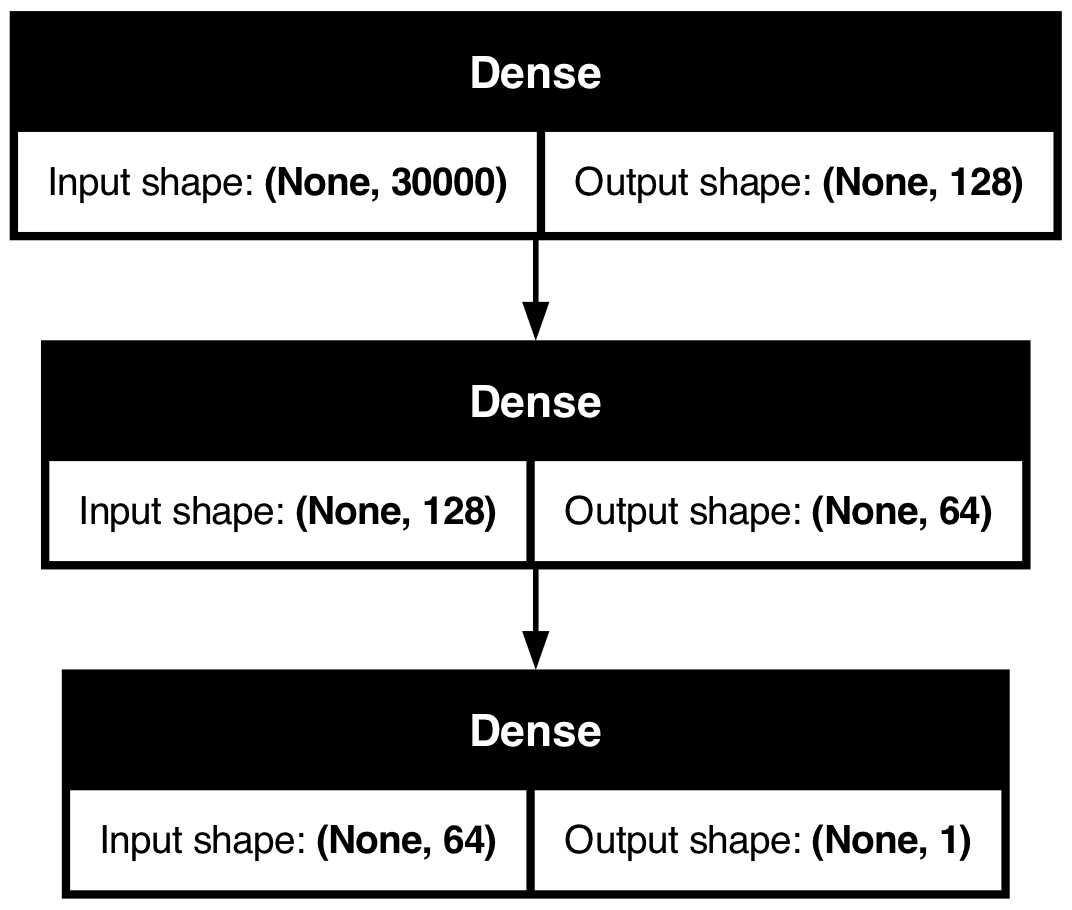

In [14]:
# plotar e salvar a arquitetura do modelo
keras.utils.plot_model(model, to_file="images/model_architecture.png", show_shapes=True)

Todos os parâmetros de uma camada podem ser acessados por meio de seus métodos *get_weights()* e *set_weights()*. Para uma camada *Dense*, isso incui os pesos de conexão e os vieses.

In [15]:
# acessar parâmetros de uma camada específica
weights, biases = model.layers[0].get_weights() # camada densa 1
print("Pesos da camada densa 1:", weights)
print("Biases da camada densa 1:", biases)

print("Formato dos pesos da camada densa 1:", weights.shape)
print("Formato dos biases da camada densa 1:", biases.shape)

Pesos da camada densa 1: [[ 7.9762032e-03 -9.0689231e-03  4.5325710e-03 ...  8.9874631e-03
   4.6686335e-03  2.7615549e-03]
 [ 1.2197628e-02  1.8552644e-03 -7.4889543e-03 ...  1.0627541e-02
  -9.9473940e-03  5.6467066e-03]
 [-2.8025722e-03  7.4091507e-03  4.7054524e-03 ... -4.6357587e-03
  -9.9934824e-03 -1.2099536e-02]
 ...
 [-4.0987507e-05 -5.9767412e-03 -9.7464770e-04 ... -1.1406727e-03
   7.0312312e-03 -5.4206308e-03]
 [ 6.2242029e-03 -1.0805093e-02 -2.2031693e-03 ... -1.3570338e-02
  -1.2382712e-02 -1.2179035e-02]
 [-3.7309397e-03 -1.3551773e-02  1.3976402e-02 ...  4.7663515e-03
   1.0215025e-03  1.3862702e-02]]
Biases da camada densa 1: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

A camada *Dense* inicializou os pesos de conexão aleatoriamente, por que isso?

É importante inicializar todos os pesos de conexão das camadas ocultas aleatoriamente ou o treinamento irá por água abaixo. Por exemplo, se você inicializar todos os pesos e vieses para zero, todos os neurônios em uma determinada camada serão perfeitamente idênticos, assim o backpropagation os afetará exatamente da mesma forma, de modo que eles permaneçam idênticos. Mesmo tendo centenas de neurônios por camada, seu modelo se comportará como se tivesse apenas um neurônio por camada: ele não será muito inteligente. Inicializando aleatoriamente os pesos, você quebra a simetria e permite que o backpropagation treine uma equipe diversificada de neurônios.

Os vieses foram inicializados em zero, o que é bom. Caso queira usar uma estratégia de inicialização diferente, poderá definir *kernel_initializer* ou *bias_initializer* quando criar a camada.
***

O formato da matriz de peso depende do número de entradas. Por isso, recomenda-se especificar a *input_shape* quando se cria a primeira camada em um modelo *Sequential*. Contudo, se você não especificar o formato de entrada, não tem problema: a Keras simplesmente aguardará até saber o formato da entrada, antes de criar o modelo. Isso acontecerá quando você alimentar com dados reais (durante o treinamento) ou quando você chamar o método *build()*. Nesse caso, até que o modelo seja de fato construído, as camadas não terão pesos e você não poderá fazer determinadas coisas (como exibir o sumário do modelo ou salvar o modelo). Assim, se você conhece o formato da entrada ao criar o modelo, é melhor especificá-lo.

In [16]:
# compilação do modelo
model.compile(
    optimizer="sgd",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Após a criação de um modelo, você deve chamar seu método *compile()* para especificar a função de perda e o otimizador a ser usado.

Como estamos fazendo uma classificação binária, utilizamos a perda *binary_crossentropy*. Se tivéssemos rótulos esparsos (ou seja, para cada instância, temos mais do que apenas duas classes possíveis) teríamos que utilizar *sparse_categorical_crossentropy*. Se tivéssemos uma probabilidade alvo por classe para cada instância (como vetores one-hot), então precisaríamos usar o *categorical_crossentropy*.

No que diz respeito ao otimizador, "sgd" significa que treinaremos o modelo empregando um gradiente descendente estocástico simples.

Como esse é um classificador, é útil calcular uma métrica de desempenho, nesse caso *accuracy* foi o escolhido durante o treinamento e avaliação.

In [17]:
# treinando e avaliando o modelo
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5243 - loss: 0.6927 - val_accuracy: 0.5620 - val_loss: 0.6918
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5814 - loss: 0.6906 - val_accuracy: 0.5424 - val_loss: 0.6892
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6817 - loss: 0.6869 - val_accuracy: 0.7684 - val_loss: 0.6845
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7369 - loss: 0.6817 - val_accuracy: 0.7188 - val_loss: 0.6785
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7547 - loss: 0.6744 - val_accuracy: 0.7812 - val_loss: 0.6698
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7953 - loss: 0.6638 - val_accuracy: 0.7616 - val_loss: 0.6572
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7981 - loss: 0.6477 - val_accuracy: 0.8090 - val_loss: 0.6377
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8123 - loss: 0.6232 - val_accuracy: 0.

Nós passamos a ele as características de entrada (X_train) e as classes-alvo (y_train), bem como o número de épocas a serem treinadas. Passamos também um conjunto de validação (isso é opcional). A Keras calculará a perda e as métricas extras nese conjunto, no fim de cada época, o que é de grande ajuda para conferir o desempenho do modelo. 

Em vez de passar um conjunto de validação utilizando o argumento *validation_data*, é possível definir *validation_split* em relação a proporção do conjunto de treinamento que você deseja que a Keras use para validação. Por exemplo, o *validation_split=0.1* informa a biblioteca Keras para usar os últimos 10% dos dados (antes de embaralhá-los) para validação.

Se o conjunto de treinamento estiver muito assimétrico, com algumas classes sendo representadas em excesso e outras sendo representadas de menos, seria útil definir o argumento *class_weight* ao chamar o método *fit()*, que daria um peso maior as classes menos representadas e um peso menor as classes representadas em excesso. Esses pesos seriam utilizados pela Keras ao calcular a perda. Se precisar dos pesos por instância, defina o argumento *sample_weight* (ele substitui a *class_weight*). Os pesos por instância podem ser vantajosos se algumas instâncias forem rotuladas por especialistas, enquanto outras forem rotuladas usando uma plataforma crowdsourcing: você pode dar mais peso a anterior. Você também pode fornecer pesos de amostra (mas não pesos de classe) para o conjunto de validação, adicionando-os como um terceiro item na tupla *validation_data*.

In [20]:
# verificar os resultados do treinamento
print("Parâmetros de treinamento:", history.params)
print("Épocas de treinamento:", history.epoch)
print("Métricas de treinamento:", history.history)
pd.DataFrame(history.history)

Parâmetros de treinamento: {'verbose': 'auto', 'epochs': 30, 'steps': 625}
Épocas de treinamento: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Métricas de treinamento: {'accuracy': [0.5242999792098999, 0.5813500285148621, 0.6816999912261963, 0.7368999719619751, 0.7547000050544739, 0.7953000068664551, 0.7980999946594238, 0.8123000264167786, 0.8233000040054321, 0.8334500193595886, 0.845550000667572, 0.8577499985694885, 0.8673499822616577, 0.878250002861023, 0.8880000114440918, 0.8947499990463257, 0.9003499746322632, 0.9046499729156494, 0.9103999733924866, 0.9157000184059143, 0.9205999970436096, 0.9245499968528748, 0.930400013923645, 0.9323999881744385, 0.9366499781608582, 0.9413999915122986, 0.9437500238418579, 0.947950005531311, 0.9524000287055969, 0.9552000164985657], 'loss': [0.6926632523536682, 0.69057297706604, 0.6869328618049622, 0.6816898584365845, 0.6744170188903809, 0.6638079881668091, 0.6477371454238892, 0.623223

,accuracy,loss,val_accuracy,val_loss
0,0.52430,0.692663,0.5620,0.691849
1,0.58135,0.690573,0.5424,0.689186
2,0.68170,0.686933,0.7684,0.684481
3,0.73690,0.681690,0.7188,0.678493
4,0.75470,0.674417,0.7812,0.669821
5,0.79530,0.663808,0.7616,0.657240
6,0.79810,0.647737,0.8090,0.637696
7,0.81230,0.623223,0.8252,0.607855
8,0.82330,0.587151,0.8280,0.565572
9,0.83345,0.538300,0.8352,0.512788


O método *fit()* retorna um objeto *History* contendo os parâmetros de treinamento, a lista de épocas pelas quais passou e um dicionário contendo a perda e as métricas extras calculadas no fim de cada época no conjunto de treinamento e no conjunto de validação (se houver). 

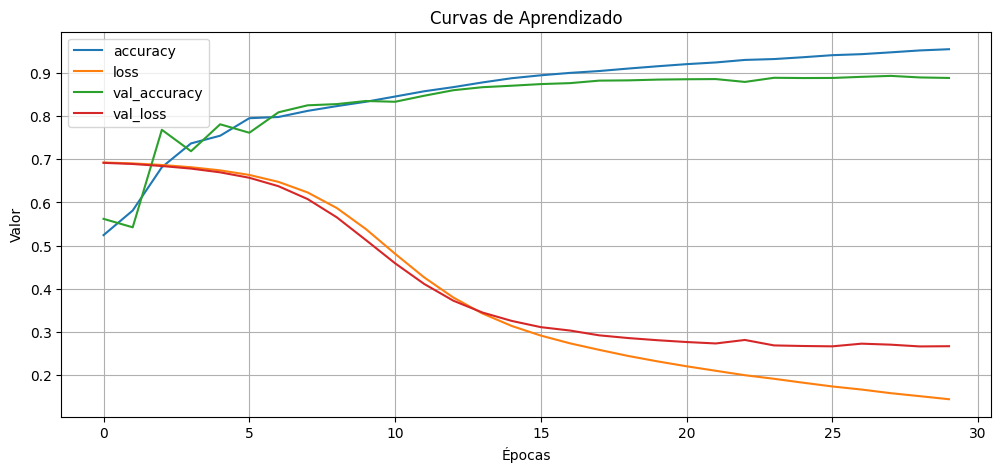

In [23]:
# plotar as curvas de aprendizado
pd.DataFrame(history.history).plot(figsize=(12, 5))
plt.title("Curvas de Aprendizado")
plt.xlabel("Épocas")
plt.ylabel("Valor")
plt.grid()
plt.show()

Você pode observar que tanto a acurácia do treinamento quanto a acurácia de validação aumentam progressivamente durante o treinamento, ao passo que a perda do treinamento e a perda de validação diminuem. Isso é um resultado positivo. Além disso, as curvas de validação estão relativamente próximas das curvas de treinamento, o que significa que não temos um overfitting em excesso. 

Nesse caso específico, aparentemente o modelo tem um desempenho melhor no conjunto de validação do que no conjunto de treinamento, no início do treinamento. Só que esse não é o caso: na verdade, o erro de validação é calculado no fim de cada época. Assim, a curva de treinamento deve ser deslocada em meia época para a esquerda. Se fizer isso, verá que as curvas de treinamento e validação se sobrepõem quase perfeitamente no início do treinamento.

> Ao plotar a curva de treinamento, ela deve ser deslocada em meia época para a esquerda.

O desempenho do conjunto de treinamento acaba superando o desempenho da validação, como acontece em geral quando você treina por tempo suficiente. É possível afirmar que o modelo ainda não convergiu, pois a perda de validação ainda está diminuindo, então, você provavelmente deve continuar o treinamento. Se você chamar o método *fit()* novamente, a Keras prossegue o treinamento de onde parou.
***

Caso não fique satisfeito com o desempenho do seu modelo, volte e ajuste os hiperparâmetros. O primeiro a ser verificado é a taxa de aprendizado. Se isso não ajudar, teste outro otimizador (e sempre reajuste a taxa de aprendizado depois de alterar qualquer hiperparâmetro). Se o desempenho ainda não for bom, tente ajustar outros hiperparâmetros como: número de camadas, números de neurônios por camada, os tipos de função de ativação a serem usadas para cada camada oculta e tamanho do batch.

In [24]:
# avaliando o modelo no conjunto de teste
X_test = pipeline.transform(df_test["text"].values)
y_test = df_test["label"].values

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Perda no conjunto de teste:", test_loss)
print("Acurácia no conjunto de teste:", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8760 - loss: 0.2960
Perda no conjunto de teste: 0.2959948480129242
Acurácia no conjunto de teste: 0.8759599924087524


É normal obter no conjunto de testes um desempenho um pouco menor do que no conjunto de validação. porque os hiperparâmetros são ajustados no conjunto de validação, e não no de testes. 

> Nunca ajuste os hiperparâmetros no conjunto de dados de testes, senão sua estimativa do erro de generalização será muito otimista (overfitting).

In [ ]:
# usando o modelo para fazer previsões